## Assignment 0: UserProxyAgent Integration in SoM Teams

#### AI-Driven Restaurant Menu Optimizer


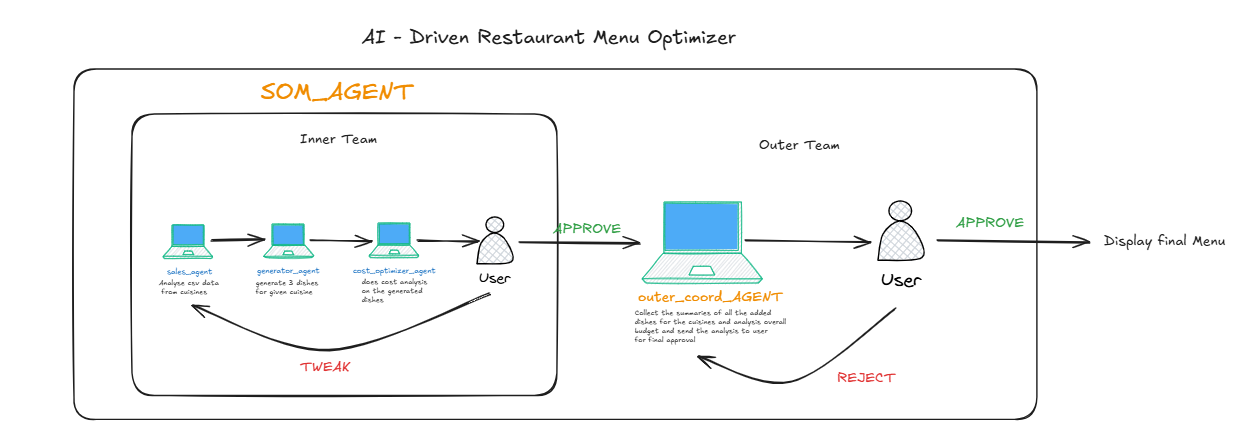

In [1]:
import asyncio
from autogen_agentchat.ui import Console
from autogen_agentchat.agents import AssistantAgent, SocietyOfMindAgent, UserProxyAgent
from autogen_ext.models.openai import OpenAIChatCompletionClient
from autogen_agentchat.teams import RoundRobinGroupChat
from autogen_agentchat.conditions import TextMentionTermination
import pandas as pd 

In [2]:
# Load environment variables
from dotenv import load_dotenv
import os

load_dotenv(override=True)
api_key = os.getenv('OPENAI_API_KEY')

# Model client
model_client = OpenAIChatCompletionClient(model='gpt-4o', api_key=api_key)

#### Tools

In [3]:
# Folder where CSVs are located
DATA_DIR =  os.getcwd()
CUISINES = ["indian", "italian", "mexican"]


In [18]:
# This tool will be used to analyze sales data for a given cuisine.
# It reads a CSV file, computes top sellers, profit margins, and other statistics.

def analyze_sales(cuisine: str) -> str:
    """Read `<cuisine>.csv`, compute top sellers and simple stats.
    Expected CSV columns: dish_name, sold_units, unit_price, ingredient_cost
    """
    path = os.path.join(DATA_DIR, f"{cuisine}.csv")
    if not os.path.exists(path):
        return f"File not found: {path}"

    df = pd.read_csv(path)
    # compute profit_margin per row
    df["profit_margin"] = ((df["unit_price"] - df["ingredient_cost"]) / df["unit_price"]) * 100
    top_sellers = df.sort_values(by="sold_units", ascending=False).head(5)

    avg_margin = df["profit_margin"].mean()
    total_cost = (df["ingredient_cost"] * df["sold_units"]).sum()

    summary = [
        f"Cuisine: {cuisine}",
        "Top sellers (dish - sold_units - profit_margin%):",
    ]
    for _, r in top_sellers.iterrows():
        summary.append(f" - {r['dish_name']} - {int(r['sold_units'])} - {r['profit_margin']:.1f}%")

    summary.append(f"Average profit margin: {avg_margin:.1f}%")
    summary.append(f"Estimated ingredient cost (period): ${total_cost:.2f}")

    return "\n".join(summary)

In [5]:
analyze_sales("indian")

'Cuisine: indian\nTop sellers (dish - sold_units - profit_margin%):\n - Samosa - 150 - 74.9%\n - Butter Chicken - 120 - 53.8%\n - Biryani - 110 - 56.2%\n - Paneer Tikka - 95 - 57.1%\n - Dal Makhani - 85 - 61.1%\nAverage profit margin: 60.6%\nEstimated ingredient cost (period): $2172.50'

In [ ]:
# cost_optimize will be used to estimate profit margins for proposed dishes.
# It will mock margins based on dish names and return a formatted string.

def cost_optimize(cuisine: str, dishes_text: str) -> str:
    """Return profit margin estimates for the proposed dishes.
    Here we mock margins; in real code you'd compute from ingredient lists.
    """
    # Parse dish names roughly
    dishes = [line.strip().lstrip("- ") for line in dishes_text.splitlines() if line.strip()]
    # Mock margins
    result = [f"Cost check for {cuisine} proposals:"]
    for i, d in enumerate(dishes[:5], start=1):
        # produce varying margins
        margin = 30 + (i * 5) - (len(d) % 7)
        result.append(f" - {d}: estimated margin {margin:.1f}%")
    return "\n".join(result)

In [ ]:
cost_optimize('indian', result)

In [ ]:
# ----------------- Outer coordinator agent -----------------
# Outer coordinator will accept cuisine summaries and perform budgeting / balancing checks.
# We'll implement it as an AssistantAgent with a small tool that evaluates budgets.

def outer_budget_check(cuisine_summaries: str, budget: float) -> str:
    """Simple check that parses the cuisine summaries and computes a mocked total cost.
    The input will be the concatenation of per-cuisine SoM outputs.
    """
    # For demo purposes we'll look for a line like 'Estimated ingredient cost (period): $1234.56'
    total = 0.0
    lines = cuisine_summaries.splitlines()
    for line in lines:
        if "Estimated ingredient cost" in line:
            try:
                dollar = line.split("$")[-1]
                total += float(dollar)
            except Exception:
                pass
    out = [f"Detected estimated total ingredient cost: ${total:.2f}", f"Budget: ${budget:.2f}"]
    if total > budget:
        out.append("Status: OVER BUDGET")
        over = total - budget
        out.append(f"Required reduction or reallocation: ${over:.2f}")
    else:
        out.append("Status: WITHIN BUDGET")
    return "\n".join(out)




#### Inner Team

In [8]:
# User Proxy Agent resopnse function
# This function will be used to handle user input in the console.
# It will return specific commands based on user input.

def custom_input(prompt=""):
    user_text = input(prompt).strip()
    if user_text.upper() == "APPROVE":
        #terminate_flag["stop"] = True
        return "TERMINATE"
        return user_text  # just return, Console will stop next turn
    elif user_text.upper() == "REJECT":
        return "Please do no add these dishes to the menu."
    elif user_text.upper() == "TWEAK":
        return "Please improve or adjust the previous answer."
    else:
        return user_text

In [9]:
def outer_custom_input(prompt=""):
    user_text = input(prompt).strip()
    if user_text.upper() == "APPROVE":
        #terminate_flag["stop"] = True
        return "TERMINATE"
        return user_text  # just return, Console will stop next turn
    elif user_text.upper() == "REJECT":
        return "Please do no make any changes to the menu."
    else:
        return user_text

In [19]:
def build_inner_team(cuisine: str):
    """
    Returns a SocietyOfMindAgent that wraps a RoundRobin inner team for one cuisine.
    The inner team members are AssistantAgents that know how to call the deterministic tools above.
    Termination is driven by the human saying 'APPROVE' at the user-proxy checkpoint.
    """
    # SalesDataAgent: has access to analyze_sales
    sales_agent = AssistantAgent(
        name=f"{cuisine}_sales",
        description="You can load sales data for indian.csv, italian.csv, and mexican.csv cuisines and calculate profit margins.",
        model_client=model_client,
        system_message=(
            f'''You are SalesDataAgent for {cuisine}. Use the tool analyze_sales(cuisine) to summarize past sales. 
            '''
        ),
        tools=[analyze_sales],
    )

    # MenuItemGeneratorAgent
    generator_agent = AssistantAgent(
        name=f"{cuisine}_generator",
        description="You can generate new menu items based on sales data and cuisine context.",
        model_client=model_client,
        system_message=(
            f"You are MenuItemGeneratorAgent for {cuisine}. Use analyze_sales output to propose 3 candidate dishes  ."
        ),
    )

    # CostOptimizerAgent
    cost_agent = AssistantAgent(
        name=f"{cuisine}_costopt",
        description="You can estimate profit margins for proposed dishes and flag low-margin items.",
        model_client=model_client,
        system_message=(
            f"You are CostOptimizerAgent for {cuisine}. Use cost_optimize(cuisine, dishes_text) to estimate margins and flag low-margin dishes. If user approves, add the proposed dishes to the final menu and show final menu after adding the dishes."
        ),
        tools=[cost_optimize],
    )

    # UserProxyAgent (human) - exposed as a tool so LLM can call user_proxy_interaction
    user_proxy = UserProxyAgent(
        name=f"{cuisine}_userproxy",
        description='you are a user proxy agent',    
        input_func=custom_input
    )


    # Termination: wait for the UserProxyAgent to return the word APPROVE
    inner_termination = TextMentionTermination("TERMINATE")

    inner_team = RoundRobinGroupChat(
        [sales_agent, generator_agent, cost_agent, user_proxy],
        termination_condition=inner_termination,
        max_turns=8,
    )


    som_agent = SocietyOfMindAgent(
            name=f"{cuisine}_society",
            description=f"Society of Mind for {cuisine} cuisine menu generation",
            team=inner_team,
            model_client=model_client,
            response_prompt=(
                f"Produce a concise, human-readable, approved menu summary for {cuisine} (list approved dishes and margins)."
            ),
        )
    
    return som_agent



### Outer Team


In [20]:
outer_coord_agent = AssistantAgent(
    name="outer_coordinator",
    description="You are the OuterTeamCoordinator. Collect per-cuisine menus and check overall budget/variety.",
    model_client=model_client,
    system_message=(
        '''You will be given the final summaries for each cuisine.\n"
        "1. List all approved dishes with their margins per cuisine.\n"
        "2. Use outer_budget_check tool to check budget.\n"
        "3. Provide a final, combined human-readable summary.\n"
        "4. Ask the human to APPROVE, REJECT, or TWEAK.\n
         5. I user APPROVES add the proposed dishes to the final menu and show final menu after adding the dishes."
        '''
    ),
    tools=[outer_budget_check],
    reflect_on_tool_use=True
)

# UserProxyAgent (human) - exposed as a tool so LLM can call user_proxy_interaction
outer_user_proxy = UserProxyAgent(
    name=f"outer_userproxy",
    description='you are a super user proxy agent, your decison will be final and you will approve or reject the menu proposals, the outer coordinator will show you the final menu summary and explain if reason for budget overrun or variety issues. and ask user to approve or reject the final menu or particular cuisine menu.',    
    input_func=outer_custom_input
)


In [21]:
som_agents = [build_inner_team(c) for c in CUISINES]

In [22]:
som_agents

In [23]:




task = (
  "Plan a monthly menu: For each cuisine (indian, italian, mexican) propose up to 3 new dishes, "
        "check their profitability, and produce an approved per-cuisine menu. Then check the overall ingredient budget "
        "(assume budget=$2800). Ask the human (user) at the indicated checkpoints to APPROVE or REJECT proposals."
   )

print("Starting Menu Optimizer. You will be prompted at human checkpoints.\n")

outer_termination = TextMentionTermination("TERMINATE")
outer_team = RoundRobinGroupChat([*som_agents,outer_coord_agent,outer_user_proxy], max_turns=10,
                                  termination_condition=outer_termination,
                                  )

stream = outer_team.run_stream(task=task)
await Console(stream)

Starting Menu Optimizer. You will be prompted at human checkpoints.

---------- TextMessage (user) ----------
Plan a monthly menu: For each cuisine (indian, italian, mexican) propose up to 3 new dishes, check their profitability, and produce an approved per-cuisine menu. Then check the overall ingredient budget (assume budget=$2800). Ask the human (user) at the indicated checkpoints to APPROVE or REJECT proposals.
---------- ToolCallRequestEvent (indian_sales) ----------
[FunctionCall(id='call_IunWiHrsVY8cUCi32kV5XK5X', arguments='{"cuisine": "indian"}', name='analyze_sales'), FunctionCall(id='call_qOzcBibacVQVdTtXcnbyBGe3', arguments='{"cuisine": "italian"}', name='analyze_sales'), FunctionCall(id='call_bMcSl4XUj5skeS0DEv6Lg8at', arguments='{"cuisine": "mexican"}', name='analyze_sales')]
---------- ToolCallExecutionEvent (indian_sales) ----------
[FunctionExecutionResult(content='Cuisine: indian\nTop sellers (dish - sold_units - profit_margin%):\n - Samosa - 150 - 74.9%\n - Butter Chi

TaskResult(messages=[TextMessage(id='94beadbe-8bc2-49d2-9c42-921718cc1def', source='user', models_usage=None, metadata={}, created_at=datetime.datetime(2025, 8, 10, 7, 56, 31, 878552, tzinfo=datetime.timezone.utc), content='Plan a monthly menu: For each cuisine (indian, italian, mexican) propose up to 3 new dishes, check their profitability, and produce an approved per-cuisine menu. Then check the overall ingredient budget (assume budget=$2800). Ask the human (user) at the indicated checkpoints to APPROVE or REJECT proposals.', type='TextMessage'), ToolCallRequestEvent(id='d0090f40-9b4f-496d-90eb-fa6912024fcf', source='indian_sales', models_usage=RequestUsage(prompt_tokens=167, completion_tokens=67), metadata={}, created_at=datetime.datetime(2025, 8, 10, 7, 56, 33, 888330, tzinfo=datetime.timezone.utc), content=[FunctionCall(id='call_IunWiHrsVY8cUCi32kV5XK5X', arguments='{"cuisine": "indian"}', name='analyze_sales'), FunctionCall(id='call_qOzcBibacVQVdTtXcnbyBGe3', arguments='{"cuisine